# Threats analysis

Load the canonical processed evidence corpus and inspect its basic structure.

In [1]:
import ast
import json
import sys
import textwrap
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import pandas as pd

In [2]:
BIODIVERSITY = {
    "primary": "#2E7D32",
    "context": "#B8CDB2",
    "pale": "#DCEAD7",
    "eligible": "#67A84B",
    "ineligible": "#D95F5F",
    "unclear": "#C49A00",
    "screening": "#6F91C7",
    "ink": "#2B2B2B",
    "neutral": "#D9D9D9",
    "paper": "#FFFFFF",
}

# Custom, nature-oriented palette for the IUCN threat L0 classes.
# Keys match the labels used in pred_threat_l0 exactly.
THREAT_L0_COLORS = {
    "Residential & Commercial Development": "#C65A46",
    "Agriculture & Aquaculture": "#D6A62E",
    "Energy Production & Mining": "#4F5559",
    "Transportation & Service Corridors": "#607D97",
    "Biological Resource Use": "#2F7D4F",
    "Human Intrusions & Disturbance": "#B65C86",
    "Natural System Modifications": "#2A9187",
    "Invasive & Other Problematic Species, Genes & Diseases": "#7656A5",
    "Pollution": "#9A9F35",
    "Geological Events": "#8B6A4F",
    "Climate Change & Severe Weather": "#2878A9",
    "Other Options": "#A9ADB0",
    "Unclear": BIODIVERSITY["unclear"],
}

THREAT_L0_CODES = {
    "Residential & Commercial Development": "1",
    "Agriculture & Aquaculture": "2",
    "Energy Production & Mining": "3",
    "Transportation & Service Corridors": "4",
    "Biological Resource Use": "5",
    "Human Intrusions & Disturbance": "6",
    "Natural System Modifications": "7",
    "Invasive & Other Problematic Species, Genes & Diseases": "8",
    "Pollution": "9",
    "Geological Events": "10",
    "Climate Change & Severe Weather": "11",
    "Other Options": "12",
    "Unclear": "U",
}

THREAT_L0_ORDER = list(THREAT_L0_COLORS)

# Exclude the incomplete 2026 publication year from all time-based outputs.
ANALYSIS_END_YEAR = 2025

In [3]:
PROJECT_ROOT = Path.cwd().parent.parent if Path.cwd().name == "results" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from data_helpers import results_config
from data_helpers.prep import evidence_corpus_prep

PUBLICATION_STYLE = PROJECT_ROOT / ".claude/skills/scientific-visualization/assets/publication.mplstyle"
plt.style.use(PUBLICATION_STYLE)

# The style enables constrained_layout globally, but every figure in this notebook
# uses manual fig.subplots_adjust(...). With constrained_layout left on, a later
# fig.set_layout_engine("none") resolves to a fragile ConstrainedLayoutEngine that
# crashes on colorbar gridspecs (ZeroDivisionError: float division by zero). Turning
# it off makes figures use plain manual layout, which is what every cell here expects.
plt.rcParams["figure.constrained_layout.use"] = False

## Output convention

Save every figure and result table under `notebooks/results/outputs/threats_supplementary/<section>/<format>/`.

- `publication-year/` contains the temporal analysis.
- `realms/` contains the aggregate and study-design realm analyses.
- `geography/` contains the country and subregion analyses.
- Each section uses `pdf/` for figures and `csv/` for tables. Figures are exported as vector PDF only.

In [4]:
OUTPUT_DIR = PROJECT_ROOT / "notebooks/results/outputs/threats_supplementary"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_SECTION_PREFIXES = {
    "annual_": "publication_year",
    "realm_": "realms",
    "study_design_": "realms",
    "geo_": "geography",
}

FIGURE_EXPORT_HELPER_DIR = (
    PROJECT_ROOT / ".claude/skills/scientific-visualization/scripts"
)
if str(FIGURE_EXPORT_HELPER_DIR) not in sys.path:
    sys.path.insert(0, str(FIGURE_EXPORT_HELPER_DIR))

from figure_export import save_publication_figure


def result_directory(filename: str, file_format: str) -> Path:
    section = next(
        (section for prefix, section in OUTPUT_SECTION_PREFIXES.items() if filename.startswith(prefix)),
        None,
    )
    if section is None:
        raise ValueError(f"Add an output-section prefix mapping for: {filename}")
    output_directory = OUTPUT_DIR / section / file_format
    output_directory.mkdir(parents=True, exist_ok=True)
    return output_directory


def save_figure_result(fig, filename: str):
    # Figures from this notebook are intentionally exported as PDF only.
    fig.set_layout_engine("none")
    return save_publication_figure(
        fig,
        result_directory(filename, "pdf") / filename,
        formats=["pdf"],
        facecolor=BIODIVERSITY["paper"],
    )


def save_table_result(table: pd.DataFrame, filename: str) -> Path:
    output_path = result_directory(filename, "csv") / f"{filename}.csv"
    table.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")
    return output_path

In [5]:
RESULTS_CONFIG = results_config.load_results_config()
EVIDENCE_CONFIG = RESULTS_CONFIG["biodiversity_evidence_prep"]
corpus_df = evidence_corpus_prep.BiodiversityEvidenceStore(
    PROJECT_ROOT / EVIDENCE_CONFIG["output_directory"]
).load(columns=[
    "UT", "publication_year", "s2_dir", "realm", "pred_threat_l0",
    "pred_regions", "pred_subregions", "pred_countries", "pred_study_design",
    "pred_methods_data_collection", "pred_methods_analysis",
    "pred_has_comparison", "pred_comparison_types",
]).publications

In [6]:
corpus_df.shape

(605199, 13)

In [7]:
eligible_negative_mask = corpus_df["s2_dir"].eq("negative")
eligible_negative_df = corpus_df.loc[eligible_negative_mask].copy()
eligible_negative_count = len(eligible_negative_df)
print(f"Of all eligible records, {eligible_negative_count:,} report a negative impact on biodiversity.")


Of all eligible records, 253,081 report a negative impact on biodiversity.


In [8]:
eligible_negative_df.shape

(253081, 13)

In [9]:
eligible_negative_df.columns

Index(['UT', 'publication_year', 's2_dir', 'realm', 'pred_threat_l0',
       'pred_regions', 'pred_subregions', 'pred_countries',
       'pred_study_design', 'pred_methods_data_collection',
       'pred_methods_analysis', 'pred_has_comparison',
       'pred_comparison_types'],
      dtype='object')

## Threat distribution by publication year

Annual counts are shown as small multiples with a shared scale and direct labels. A record can have more than one `pred_threat_l0` label, so a multi-label record contributes once to each of its assigned threats.

In [10]:
def parse_list_labels(value) -> list[str]:
    """Return a clean, de-duplicated list from list values or serialized lists."""
    if isinstance(value, (list, tuple, set)):
        raw_labels = list(value)
    elif pd.isna(value):
        return []
    else:
        text = str(value).strip()
        if not text or text.casefold() in {"nan", "none", "null"} or text == "[]":
            return []

        raw_labels = None
        if text.startswith("[") and text.endswith("]"):
            for parser in (json.loads, ast.literal_eval):
                try:
                    parsed = parser(text)
                except (ValueError, SyntaxError, TypeError):
                    continue
                if isinstance(parsed, (list, tuple, set)):
                    raw_labels = list(parsed)
                    break

        if raw_labels is None:
            raw_labels = text.split(";") if ";" in text else [text]

    labels = []
    for raw_label in raw_labels:
        if raw_label is None:
            continue
        label = str(raw_label).strip()
        if label and label not in labels:
            labels.append(label)
    return labels

In [11]:
threat_year_long = eligible_negative_df[["UT", "publication_year", "pred_threat_l0"]].copy()
threat_year_long["publication_year"] = pd.to_numeric(
    threat_year_long["publication_year"], errors="coerce"
).astype("Int64")
threat_year_long = threat_year_long.loc[
    threat_year_long["publication_year"].le(ANALYSIS_END_YEAR)
]
threat_year_long["pred_threat_l0"] = threat_year_long["pred_threat_l0"].map(parse_list_labels)
threat_year_long = (
    threat_year_long
    .explode("pred_threat_l0")
    .dropna(subset=["publication_year", "pred_threat_l0"])
)
threat_year_long["pred_threat_l0"] = threat_year_long["pred_threat_l0"].astype("string").str.strip()
threat_year_long = (
    threat_year_long.loc[threat_year_long["pred_threat_l0"].ne("")]
    .drop_duplicates(["UT", "publication_year", "pred_threat_l0"])
)

observed_threats = set(threat_year_long["pred_threat_l0"])
unconfigured_threats = sorted(observed_threats.difference(THREAT_L0_COLORS))
if unconfigured_threats:
    raise ValueError(f"Add colors for unexpected pred_threat_l0 labels: {unconfigured_threats}")

threat_year_counts = (
    threat_year_long
    .groupby(["publication_year", "pred_threat_l0"], observed=True)["UT"]
    .nunique()
    .rename("record_count")
    .reset_index()
)
plot_threat_order = (
    threat_year_counts
    .groupby("pred_threat_l0", observed=True)["record_count"]
    .sum()
    .sort_values(ascending=False)
    .index
    .tolist()
)

year_record_counts = (
    eligible_negative_df.assign(
        publication_year=pd.to_numeric(eligible_negative_df["publication_year"], errors="coerce")
    )
    .dropna(subset=["publication_year"])
    .loc[lambda frame: frame["publication_year"].le(ANALYSIS_END_YEAR)]
    .groupby("publication_year")["UT"]
    .nunique()
    .sort_index()
)
year_record_counts.index = year_record_counts.index.astype(int)

threat_year_wide = (
    threat_year_counts
    .pivot(index="publication_year", columns="pred_threat_l0", values="record_count")
    .reindex(index=year_record_counts.index, columns=plot_threat_order, fill_value=0)
    .fillna(0)
    .astype(int)
)

threat_year_audit_table = threat_year_wide.copy()
threat_year_audit_table["unique_records"] = year_record_counts.astype(int)
threat_year_audit_table["threat_assignments"] = threat_year_wide.sum(axis=1)
threat_year_audit_table = threat_year_audit_table.reset_index()
current_year = pd.Timestamp.today().year
threat_year_audit_table.insert(
    1,
    "year_status",
    threat_year_audit_table["publication_year"].map(
        lambda year: "partial" if year == current_year else "complete"
    ),
)

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/publication_year/pdf/annual_threat_assignments.pdf


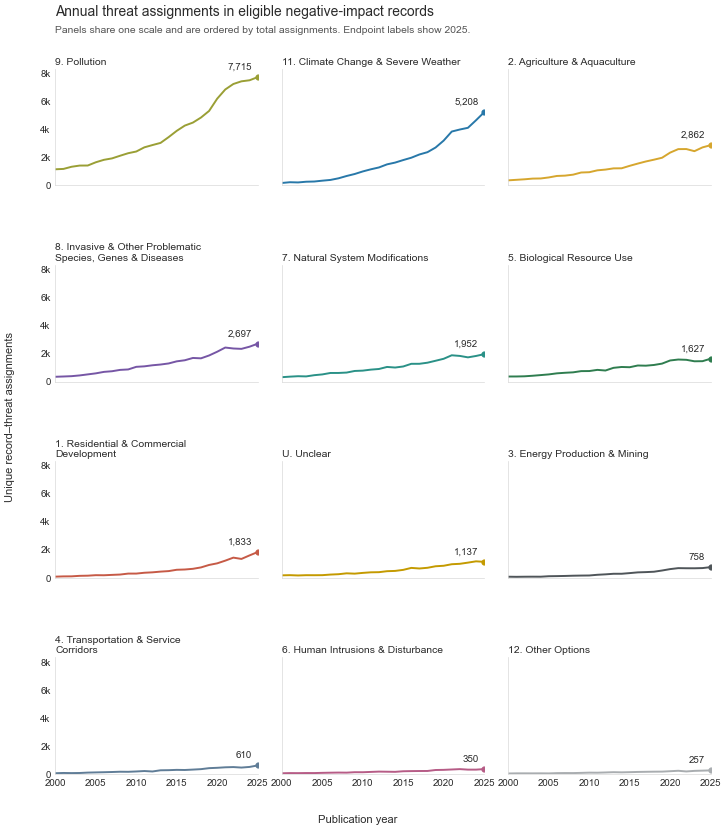

In [12]:
years = threat_year_wide.index.to_list()
tick_years = [year for year in years if year % 5 == 0]
if years and (not tick_years or years[-1] - tick_years[-1] >= 3):
    tick_years.append(years[-1])
is_partial_current_year = bool(years and years[-1] == current_year)
endpoint_position = -2 if is_partial_current_year and len(years) > 1 else -1
endpoint_year = years[endpoint_position]
n_cols = 3
n_rows = (len(plot_threat_order) + n_cols - 1) // n_cols
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(7.2, 1.8 * n_rows + 1.3),
    sharex=True,
    sharey=True,
    constrained_layout=False,
)
axes = list(axes.flat) if hasattr(axes, "flat") else [axes]
shared_y_max = int(threat_year_wide.max().max())

for panel_index, (ax, threat) in enumerate(zip(axes, plot_threat_order)):
    values = threat_year_wide[threat]
    color = THREAT_L0_COLORS[threat]

    solid_years = years[: endpoint_position + 1] if endpoint_position != -1 else years
    solid_values = values.iloc[: endpoint_position + 1] if endpoint_position != -1 else values
    endpoint_value = int(values.iloc[endpoint_position])

    ax.plot(solid_years, solid_values, color=color, linewidth=1.4)
    if is_partial_current_year:
        ax.plot(
            years[-2:],
            values.iloc[-2:],
            color=color,
            linewidth=1.1,
            linestyle=(0, (2, 2)),
            alpha=0.7,
        )
        ax.scatter(
            years[-1],
            values.iloc[-1],
            facecolor=BIODIVERSITY["paper"],
            edgecolor=color,
            linewidth=0.8,
            s=12,
            zorder=3,
        )

    ax.scatter(endpoint_year, endpoint_value, color=color, s=12, zorder=3)
    ax.annotate(
        f"{endpoint_value:,}",
        xy=(endpoint_year, endpoint_value),
        xytext=(-4, 4),
        textcoords="offset points",
        ha="right",
        va="bottom",
        fontsize=7,
        color=BIODIVERSITY["ink"],
    )
    ax.set_title(
        f"{THREAT_L0_CODES[threat]}. {textwrap.fill(threat, width=32)}",
        loc="left",
        fontsize=7.5,
        color=BIODIVERSITY["ink"],
        pad=3,
    )
    ax.set_xlim(years[0], years[-1])
    ax.set_ylim(0, shared_y_max * 1.08)
    ax.set_xticks(tick_years)
    ax.yaxis.set_major_formatter(
        lambda value, _: f"{value / 1_000:.0f}k" if value >= 1_000 else f"{value:.0f}"
    )
    ax.grid(False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color(BIODIVERSITY["neutral"])
    ax.spines[["left", "bottom"]].set_linewidth(0.5)
    ax.tick_params(length=0, colors=BIODIVERSITY["ink"], labelsize=7)

    if panel_index % n_cols != 0:
        ax.tick_params(labelleft=False)
    if panel_index < (n_rows - 1) * n_cols:
        ax.tick_params(labelbottom=False)

for ax in axes[len(plot_threat_order):]:
    ax.set_visible(False)

fig.suptitle(
    "Annual threat assignments in eligible negative-impact records",
    x=0.08,
    y=0.985,
    ha="left",
    fontsize=10,
    color=BIODIVERSITY["ink"],
)
fig.text(
    0.08,
    0.96,
    (
        f"Panels share one scale and are ordered by total assignments. Endpoint labels show {endpoint_year}; "
        f"dotted segments show partial {current_year}."
        if is_partial_current_year
        else f"Panels share one scale and are ordered by total assignments. Endpoint labels show {endpoint_year}."
    ),
    ha="left",
    va="top",
    color="#555555",
    fontsize=7.5,
)
fig.supxlabel("Publication year", y=0.02, fontsize=8, color=BIODIVERSITY["ink"])
fig.supylabel(
    "Unique record–threat assignments", x=0.01, fontsize=8, color=BIODIVERSITY["ink"]
)
fig.subplots_adjust(left=0.08, right=0.99, top=0.91, bottom=0.08, hspace=0.68, wspace=0.12)
annual_threat_figure_paths = save_figure_result(fig, "annual_threat_assignments")
plt.show()

In [13]:
annual_threat_counts_path = save_table_result(
    threat_year_counts, "annual_threat_counts_long"
)
annual_threat_audit_path = save_table_result(
    threat_year_audit_table, "annual_threat_audit"
)

display(threat_year_audit_table)

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/publication_year/csv/annual_threat_counts_long.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/publication_year/csv/annual_threat_audit.csv


pred_threat_l0,publication_year,year_status,Pollution,Climate Change & Severe Weather,Agriculture & Aquaculture,"Invasive & Other Problematic Species, Genes & Diseases",Natural System Modifications,Biological Resource Use,Residential & Commercial Development,Unclear,Energy Production & Mining,Transportation & Service Corridors,Human Intrusions & Disturbance,Other Options,unique_records,threat_assignments
0,2000,complete,1143,167,355,340,310,359,80,174,75,56,52,37,2530,3148
1,2001,complete,1169,220,392,360,349,361,98,186,68,74,65,46,2665,3388
2,2002,complete,1323,205,429,383,380,374,102,165,75,65,62,47,2879,3610
3,2003,complete,1408,255,478,436,366,413,138,184,78,72,69,45,3146,3942
4,2004,complete,1412,270,488,510,453,460,149,182,76,100,67,48,3398,4215
5,2005,complete,1644,330,562,584,508,509,185,186,110,114,82,43,3809,4857
6,2006,complete,1818,383,667,689,611,585,179,228,118,127,93,62,4375,5560
7,2007,complete,1920,499,690,735,612,625,206,254,130,142,102,68,4695,5983
8,2008,complete,2109,664,759,831,640,656,230,317,147,162,97,66,5351,6678
9,2009,complete,2290,806,913,863,754,743,298,294,157,157,128,80,5809,7483


## Threat distribution across realms

Each matrix crosses exact `pred_threat_l0` and `realm` labels. Counts are unique records. Percentages divide each realm–threat count by the unique records assigned to that realm, so they show threat prevalence within a realm. Multi-label threats can make percentages within a realm sum above 100%.

In [14]:
realm_threat_source = eligible_negative_df[[
    "UT", "realm", "pred_threat_l0", "pred_study_design"
]].copy()
realm_threat_source["realm"] = realm_threat_source["realm"].map(parse_list_labels)
realm_threat_source["pred_threat_l0"] = realm_threat_source["pred_threat_l0"].map(parse_list_labels)
realm_threat_source["study_design"] = (
    realm_threat_source["pred_study_design"]
    .fillna("Missing")
    .astype("string")
    .str.strip()
    .replace({"": "Missing"})
)

study_design_record_counts = (
    realm_threat_source
    .groupby("study_design", observed=True)["UT"]
    .nunique()
    .sort_values(ascending=False)
    .rename("record_count")
    .reset_index()
)
study_design_order = study_design_record_counts.loc[
    study_design_record_counts["study_design"].ne("Missing"), "study_design"
].tolist()

realm_threat_long = (
    realm_threat_source
    .drop(columns="pred_study_design")
    .explode("realm")
    .explode("pred_threat_l0")
    .dropna(subset=["realm", "pred_threat_l0"])
)
realm_threat_long["realm"] = realm_threat_long["realm"].astype("string").str.strip()
realm_threat_long["pred_threat_l0"] = (
    realm_threat_long["pred_threat_l0"].astype("string").str.strip()
)
realm_threat_long = (
    realm_threat_long.loc[
        realm_threat_long["realm"].ne("")
        & realm_threat_long["pred_threat_l0"].ne("")
    ]
    .drop_duplicates(["UT", "realm", "pred_threat_l0", "study_design"])
)

unexpected_threats = sorted(
    set(realm_threat_long["pred_threat_l0"]).difference(THREAT_L0_COLORS)
)
if unexpected_threats:
    raise ValueError(f"Unexpected pred_threat_l0 labels: {unexpected_threats}")

realm_order = (
    realm_threat_long
    .groupby("realm", observed=True)["UT"]
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)
threat_matrix_order = (
    realm_threat_long
    .groupby("pred_threat_l0", observed=True)["UT"]
    .nunique()
    .sort_values(ascending=False)
    .index
    .tolist()
)

In [15]:
def build_realm_threat_tables(data: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    realm_record_counts = (
        data.groupby("realm", observed=True)["UT"]
        .nunique()
        .rename("realm_record_count")
    )
    long_counts = (
        data.groupby(["realm", "pred_threat_l0"], observed=True)["UT"]
        .nunique()
        .rename("record_count")
        .reset_index()
        .merge(realm_record_counts, on="realm", how="left", validate="many_to_one")
    )
    long_counts["share_of_realm_records"] = (
        long_counts["record_count"] / long_counts["realm_record_count"]
    )

    count_matrix = (
        long_counts.pivot(
            index="pred_threat_l0", columns="realm", values="record_count"
        )
        .reindex(index=threat_matrix_order, columns=realm_order, fill_value=0)
        .fillna(0)
        .astype(int)
    )
    share_matrix = (
        long_counts.pivot(
            index="pred_threat_l0", columns="realm", values="share_of_realm_records"
        )
        .reindex(index=threat_matrix_order, columns=realm_order, fill_value=0)
        .fillna(0)
    )
    return long_counts, count_matrix, share_matrix


def plot_realm_threat_matrices(
    count_matrix: pd.DataFrame,
    share_matrix: pd.DataFrame,
    title: str,
    *,
    count_vmax: int,
    share_vmax: float,
):
    fig, (count_ax, share_ax) = plt.subplots(
        2, 1, figsize=(7.2, 8.6), constrained_layout=False
    )
    fig.set_layout_engine("none")
    count_values = count_matrix.to_numpy(dtype=float)
    count_values[count_values == 0] = np.nan
    share_values = share_matrix.to_numpy(dtype=float) * 100

    count_cmap = plt.get_cmap("cividis").copy()
    count_cmap.set_bad(BIODIVERSITY["paper"])
    count_image = count_ax.imshow(
        count_values,
        aspect="auto",
        cmap=count_cmap,
        norm=LogNorm(vmin=1, vmax=max(1, count_vmax)),
    )
    share_image = share_ax.imshow(
        share_values,
        aspect="auto",
        cmap="cividis",
        vmin=0,
        vmax=max(1, share_vmax),
    )

    threat_labels = [
        f"{THREAT_L0_CODES[threat]}. {textwrap.fill(threat, width=34)}"
        for threat in count_matrix.index
    ]
    realm_labels = count_matrix.columns.tolist()

    for ax in (count_ax, share_ax):
        ax.set_yticks(range(len(threat_labels)), labels=threat_labels)
        ax.tick_params(axis="y", length=0, labelsize=6.5, colors=BIODIVERSITY["ink"])
        ax.tick_params(axis="x", length=0, colors=BIODIVERSITY["ink"])
        for spine in ax.spines.values():
            spine.set_visible(False)

    count_ax.set_xticks([])
    count_ax.set_title("Unique record counts (log color scale)", loc="left", fontsize=8)
    share_ax.set_xticks(range(len(realm_labels)), labels=realm_labels)
    share_ax.tick_params(axis="x", labelsize=5.5, pad=2, rotation=90)
    for tick_label in share_ax.get_xticklabels():
        tick_label.set_ha("center")
        tick_label.set_va("top")
    share_ax.set_xlabel("Realm", fontsize=8, labelpad=8)
    share_ax.set_title("Share of records within each realm (%)", loc="left", fontsize=8)

    count_cbar = fig.colorbar(count_image, ax=count_ax, fraction=0.025, pad=0.015)
    count_cbar.set_label("Unique records (log scale)", fontsize=7)
    count_cbar.ax.tick_params(labelsize=6, length=0)
    share_cbar = fig.colorbar(share_image, ax=share_ax, fraction=0.025, pad=0.015)
    share_cbar.set_label("Records within realm (%)", fontsize=7)
    share_cbar.ax.tick_params(labelsize=6, length=0)

    fig.suptitle(title, x=0.31, y=0.985, ha="left", fontsize=10, color=BIODIVERSITY["ink"])
    fig.text(
        0.31,
        0.01,
        "Percentages use unique records in each realm as the denominator; multi-label threats can sum above 100%.",
        ha="left",
        va="bottom",
        fontsize=6.5,
        color="#555555",
    )
    fig.subplots_adjust(left=0.31, right=0.92, top=0.94, bottom=0.23, hspace=0.30)
    return fig

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/pdf/realm_threat_matrix_all_study_designs.pdf


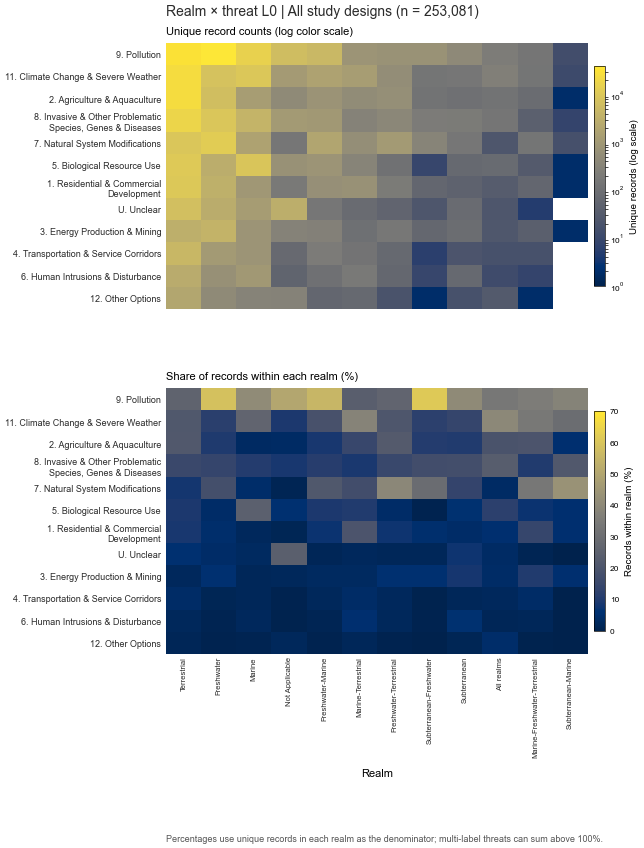

In [16]:
aggregate_realm_threat_long, aggregate_realm_threat_counts, aggregate_realm_threat_shares = (
    build_realm_threat_tables(realm_threat_long)
)
aggregate_count_vmax = int(aggregate_realm_threat_counts.to_numpy().max())
aggregate_share_vmax = float(np.ceil(aggregate_realm_threat_shares.to_numpy().max() * 10) * 10)

aggregate_realm_threat_fig = plot_realm_threat_matrices(
    aggregate_realm_threat_counts,
    aggregate_realm_threat_shares,
    f"Realm × threat L0 | All study designs (n = {eligible_negative_df['UT'].nunique():,})",
    count_vmax=aggregate_count_vmax,
    share_vmax=aggregate_share_vmax,
)
aggregate_realm_threat_figure_paths = save_figure_result(
    aggregate_realm_threat_fig, "realm_threat_matrix_all_study_designs"
)
plt.show()

In [17]:
aggregate_realm_threat_long_path = save_table_result(
    aggregate_realm_threat_long, "realm_threat_all_study_designs_long"
)
aggregate_realm_threat_counts_path = save_table_result(
    aggregate_realm_threat_counts.reset_index(),
    "realm_threat_all_study_designs_count_matrix",
)
aggregate_realm_threat_shares_path = save_table_result(
    aggregate_realm_threat_shares.reset_index(),
    "realm_threat_all_study_designs_share_matrix",
)
study_design_record_counts_path = save_table_result(
    study_design_record_counts, "study_design_record_counts"
)

print("Aggregate unique record counts")
display(aggregate_realm_threat_counts.reset_index())
print("Aggregate share of records within each realm")
# Format only the numeric realm columns; the pred_threat_l0 label column is a string.
display(aggregate_realm_threat_shares.reset_index().style.format("{:.1%}", subset=realm_order))
print("Study-design record counts; Missing is audited but is not a substantive split")
display(study_design_record_counts)

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_all_study_designs_long.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_all_study_designs_count_matrix.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_all_study_designs_share_matrix.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/study_design_record_counts.csv
Aggregate unique record counts


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,30804,39458,15376,6178,4879,788,693,709,446,213,147,14
1,Climate Change & Severe Weather,25437,7730,9886,1106,1669,1259,554,140,153,253,141,11
2,Agriculture & Aquaculture,25756,6557,1263,467,747,495,594,122,110,125,84,2
3,"Invasive & Other Problematic Species, Genes & ...",18448,9502,3920,1068,961,290,397,200,192,148,42,8
4,Natural System Modifications,9646,11962,1671,155,1891,578,1039,339,150,24,139,16
5,Biological Resource Use,10740,2848,9248,685,805,334,112,9,68,77,30,2
6,Residential & Commercial Development,10153,3235,953,181,626,668,196,60,47,33,60,2
7,Unclear,6941,2793,1209,2983,151,82,54,23,81,24,5,0
8,Energy Production & Mining,3060,3821,803,299,268,104,157,65,90,25,41,2
9,Transportation & Service Corridors,4651,1073,794,73,207,129,68,6,21,17,17,0


Aggregate share of records within each realm


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,26.0%,58.9%,41.0%,50.5%,55.7%,23.8%,26.3%,61.4%,40.7%,33.5%,35.3%,37.8%
1,Climate Change & Severe Weather,21.4%,11.5%,26.4%,9.0%,19.0%,38.0%,21.0%,12.1%,14.0%,39.8%,33.9%,29.7%
2,Agriculture & Aquaculture,21.7%,9.8%,3.4%,3.8%,8.5%,15.0%,22.5%,10.6%,10.0%,19.7%,20.2%,5.4%
3,"Invasive & Other Problematic Species, Genes & Diseases",15.6%,14.2%,10.5%,8.7%,11.0%,8.8%,15.1%,17.3%,17.5%,23.3%,10.1%,21.6%
4,Natural System Modifications,8.1%,17.9%,4.5%,1.3%,21.6%,17.5%,39.4%,29.4%,13.7%,3.8%,33.4%,43.2%
5,Biological Resource Use,9.1%,4.3%,24.7%,5.6%,9.2%,10.1%,4.3%,0.8%,6.2%,12.1%,7.2%,5.4%
6,Residential & Commercial Development,8.6%,4.8%,2.5%,1.5%,7.1%,20.2%,7.4%,5.2%,4.3%,5.2%,14.4%,5.4%
7,Unclear,5.9%,4.2%,3.2%,24.4%,1.7%,2.5%,2.0%,2.0%,7.4%,3.8%,1.2%,0.0%
8,Energy Production & Mining,2.6%,5.7%,2.1%,2.4%,3.1%,3.1%,6.0%,5.6%,8.2%,3.9%,9.9%,5.4%
9,Transportation & Service Corridors,3.9%,1.6%,2.1%,0.6%,2.4%,3.9%,2.6%,0.5%,1.9%,2.7%,4.1%,0.0%


Study-design record counts; Missing is audited but is not a substantive split


,study_design,record_count
0,Observational,116684
1,Experimental,86536
2,Modelling,33993
3,Review,12705
4,Unclear,3162
5,Missing,1


### Realm × threat matrices by study design

The count color scale is shared across study-design figures, as is the percentage scale, so color intensity remains comparable between designs.

In [18]:
realm_threat_tables_by_study_design = {}
study_design_long_tables = []

for study_design in study_design_order:
    study_data = realm_threat_long.loc[realm_threat_long["study_design"].eq(study_design)]
    long_counts, count_matrix, share_matrix = build_realm_threat_tables(study_data)
    long_counts.insert(0, "study_design", study_design)
    study_design_long_tables.append(long_counts)
    realm_threat_tables_by_study_design[study_design] = {
        "long": long_counts,
        "counts": count_matrix,
        "shares": share_matrix,
    }

realm_threat_by_study_design_long = pd.concat(study_design_long_tables, ignore_index=True)
study_design_count_vmax = max(
    int(tables["counts"].to_numpy().max())
    for tables in realm_threat_tables_by_study_design.values()
)
study_design_share_vmax = max(
    float(np.ceil(tables["shares"].to_numpy().max() * 10) * 10)
    for tables in realm_threat_tables_by_study_design.values()
)
realm_threat_by_study_design_long_path = save_table_result(
    realm_threat_by_study_design_long, "realm_threat_by_study_design_long"
)

Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_by_study_design_long.csv


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/pdf/realm_threat_matrix_study_design_observational.pdf
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_count_matrix_study_design_observational.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_share_matrix_study_design_observational.csv


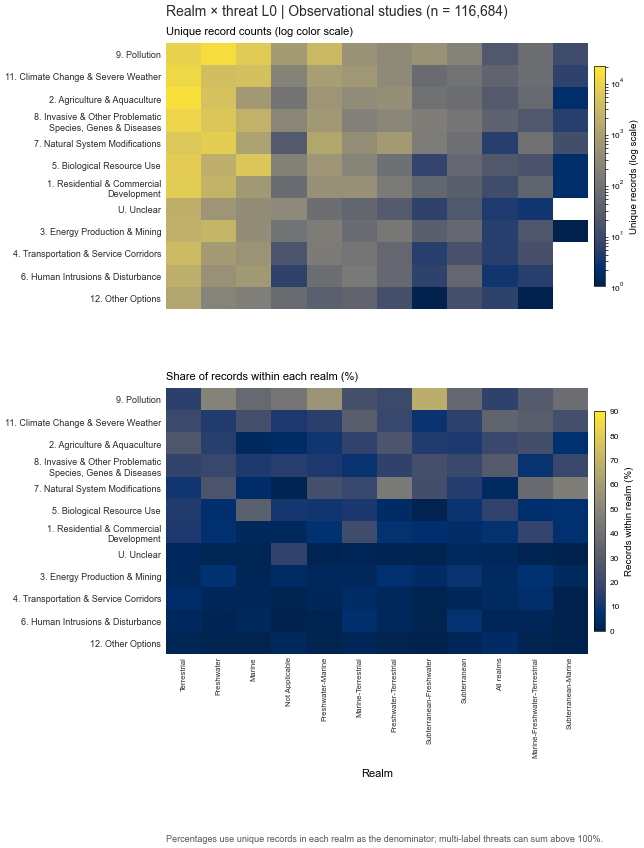

Observational: unique record counts


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,9000,14532,6364,751,3022,476,321,453,200,21,68,10
1,Climate Change & Severe Weather,11485,3866,4066,211,827,620,304,63,89,43,71,6
2,Agriculture & Aquaculture,15330,4386,667,94,541,342,419,85,68,25,53,2
3,"Invasive & Other Problematic Species, Genes & ...",9988,5730,2133,257,629,184,265,156,109,37,21,5
4,Natural System Modifications,5740,7720,1003,24,1231,384,701,152,75,5,85,12
5,Biological Resource Use,7215,1896,5627,193,542,233,82,7,52,22,16,2
6,Residential & Commercial Development,6707,2298,637,65,440,437,136,45,31,11,41,2
7,Unclear,1952,556,371,308,73,45,26,6,21,4,3,0
8,Energy Production & Mining,2039,2473,378,93,165,64,118,32,51,5,19,1
9,Transportation & Service Corridors,3214,748,488,18,144,101,49,5,15,5,14,0


Observational: share of records within each realm


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,15.8%,48.8%,36.0%,41.6%,56.4%,23.6%,20.2%,67.7%,35.8%,16.4%,29.3%,38.5%
1,Climate Change & Severe Weather,20.2%,13.0%,23.0%,11.7%,15.4%,30.7%,19.1%,9.4%,15.9%,33.6%,30.6%,23.1%
2,Agriculture & Aquaculture,26.9%,14.7%,3.8%,5.2%,10.1%,16.9%,26.4%,12.7%,12.2%,19.5%,22.8%,7.7%
3,"Invasive & Other Problematic Species, Genes & Diseases",17.5%,19.2%,12.1%,14.2%,11.7%,9.1%,16.7%,23.3%,19.5%,28.9%,9.1%,19.2%
4,Natural System Modifications,10.1%,25.9%,5.7%,1.3%,23.0%,19.0%,44.1%,22.7%,13.4%,3.9%,36.6%,46.2%
5,Biological Resource Use,12.7%,6.4%,31.9%,10.7%,10.1%,11.5%,5.2%,1.0%,9.3%,17.2%,6.9%,7.7%
6,Residential & Commercial Development,11.8%,7.7%,3.6%,3.6%,8.2%,21.6%,8.6%,6.7%,5.5%,8.6%,17.7%,7.7%
7,Unclear,3.4%,1.9%,2.1%,17.0%,1.4%,2.2%,1.6%,0.9%,3.8%,3.1%,1.3%,0.0%
8,Energy Production & Mining,3.6%,8.3%,2.1%,5.1%,3.1%,3.2%,7.4%,4.8%,9.1%,3.9%,8.2%,3.8%
9,Transportation & Service Corridors,5.6%,2.5%,2.8%,1.0%,2.7%,5.0%,3.1%,0.7%,2.7%,3.9%,6.0%,0.0%


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/pdf/realm_threat_matrix_study_design_experimental.pdf
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_count_matrix_study_design_experimental.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_share_matrix_study_design_experimental.csv


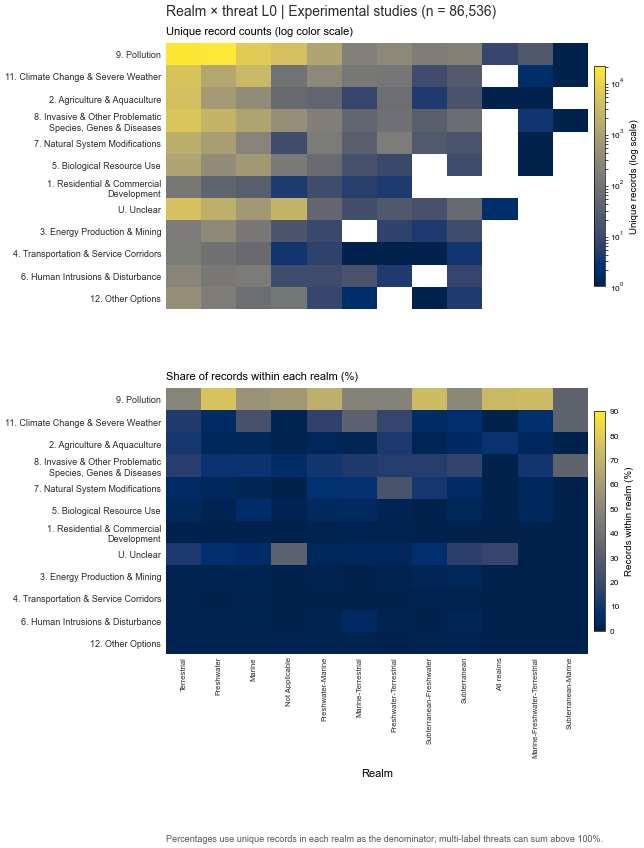

Experimental: unique record counts


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,18500,20649,6617,4286,1167,182,298,160,189,8,22,1
1,Climate Change & Severe Weather,4874,1297,2864,89,289,121,110,11,24,0,2,1
2,Agriculture & Aquaculture,3973,730,349,55,44,7,72,4,16,1,1,0
3,"Invasive & Other Problematic Species, Genes & ...",5255,2377,1096,420,180,46,83,30,64,0,3,1
4,Natural System Modifications,1757,859,228,11,141,32,151,23,17,0,1,0
5,Biological Resource Use,1164,355,674,128,63,15,9,0,10,0,1,0
6,Residential & Commercial Development,118,40,30,4,11,5,4,0,0,0,0,0
7,Unclear,4382,1996,678,2405,47,12,21,15,55,2,0,0
8,Energy Production & Mining,148,305,124,18,9,0,6,4,11,0,0,0
9,Transportation & Service Corridors,138,85,58,3,6,1,1,1,3,0,0,0


Experimental: share of records within each realm


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,49.5%,76.8%,56.6%,58.1%,68.0%,48.4%,48.9%,73.4%,51.1%,72.7%,73.3%,33.3%
1,Climate Change & Severe Weather,13.0%,4.8%,24.5%,1.2%,16.9%,32.2%,18.0%,5.0%,6.5%,0.0%,6.7%,33.3%
2,Agriculture & Aquaculture,10.6%,2.7%,3.0%,0.7%,2.6%,1.9%,11.8%,1.8%,4.3%,9.1%,3.3%,0.0%
3,"Invasive & Other Problematic Species, Genes & Diseases",14.1%,8.8%,9.4%,5.7%,10.5%,12.2%,13.6%,13.8%,17.3%,0.0%,10.0%,33.3%
4,Natural System Modifications,4.7%,3.2%,1.9%,0.1%,8.2%,8.5%,24.8%,10.6%,4.6%,0.0%,3.3%,0.0%
5,Biological Resource Use,3.1%,1.3%,5.8%,1.7%,3.7%,4.0%,1.5%,0.0%,2.7%,0.0%,3.3%,0.0%
6,Residential & Commercial Development,0.3%,0.1%,0.3%,0.1%,0.6%,1.3%,0.7%,0.0%,0.0%,0.0%,0.0%,0.0%
7,Unclear,11.7%,7.4%,5.8%,32.6%,2.7%,3.2%,3.4%,6.9%,14.9%,18.2%,0.0%,0.0%
8,Energy Production & Mining,0.4%,1.1%,1.1%,0.2%,0.5%,0.0%,1.0%,1.8%,3.0%,0.0%,0.0%,0.0%
9,Transportation & Service Corridors,0.4%,0.3%,0.5%,0.0%,0.3%,0.3%,0.2%,0.5%,0.8%,0.0%,0.0%,0.0%


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/pdf/realm_threat_matrix_study_design_modelling.pdf
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_count_matrix_study_design_modelling.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_share_matrix_study_design_modelling.csv


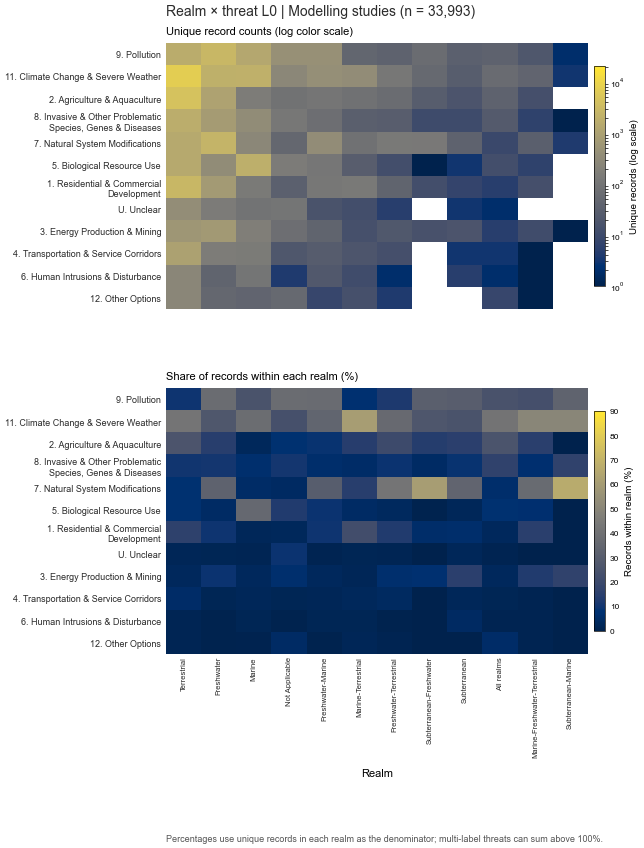

Modelling: unique record counts


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,1703,2776,1342,429,438,45,38,64,34,37,20,2
1,Climate Change & Severe Weather,7309,2001,2045,269,401,360,115,54,28,62,43,3
2,Agriculture & Aquaculture,4540,1059,153,88,106,84,65,28,17,38,13,0
3,"Invasive & Other Problematic Species, Genes & ...",1763,753,341,118,73,32,29,10,10,25,6,1
4,Natural System Modifications,1432,2397,270,49,351,86,131,124,38,9,32,4
5,Biological Resource Use,1439,341,1918,144,111,29,12,1,3,12,6,0
6,Residential & Commercial Development,2816,705,137,33,114,132,40,12,7,5,13,0
7,Unclear,374,149,93,105,16,12,5,0,3,2,0,0
8,Energy Production & Mining,566,670,173,72,41,14,21,15,17,5,11,1
9,Transportation & Service Corridors,989,154,142,20,27,18,13,0,3,3,1,0


Modelling: share of records within each realm


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,9.7%,37.9%,25.1%,37.9%,37.3%,7.6%,12.1%,31.4%,30.4%,24.7%,23.3%,33.3%
1,Climate Change & Severe Weather,41.6%,27.3%,38.2%,23.8%,34.2%,60.8%,36.5%,26.5%,25.0%,41.3%,50.0%,50.0%
2,Agriculture & Aquaculture,25.8%,14.4%,2.9%,7.8%,9.0%,14.2%,20.6%,13.7%,15.2%,25.3%,15.1%,0.0%
3,"Invasive & Other Problematic Species, Genes & Diseases",10.0%,10.3%,6.4%,10.4%,6.2%,5.4%,9.2%,4.9%,8.9%,16.7%,7.0%,16.7%
4,Natural System Modifications,8.1%,32.7%,5.0%,4.3%,29.9%,14.5%,41.6%,60.8%,33.9%,6.0%,37.2%,66.7%
5,Biological Resource Use,8.2%,4.7%,35.9%,12.7%,9.5%,4.9%,3.8%,0.5%,2.7%,8.0%,7.0%,0.0%
6,Residential & Commercial Development,16.0%,9.6%,2.6%,2.9%,9.7%,22.3%,12.7%,5.9%,6.2%,3.3%,15.1%,0.0%
7,Unclear,2.1%,2.0%,1.7%,9.3%,1.4%,2.0%,1.6%,0.0%,2.7%,1.3%,0.0%,0.0%
8,Energy Production & Mining,3.2%,9.1%,3.2%,6.4%,3.5%,2.4%,6.7%,7.4%,15.2%,3.3%,12.8%,16.7%
9,Transportation & Service Corridors,5.6%,2.1%,2.7%,1.8%,2.3%,3.0%,4.1%,0.0%,2.7%,2.0%,1.2%,0.0%


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/pdf/realm_threat_matrix_study_design_review.pdf
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_count_matrix_study_design_review.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_share_matrix_study_design_review.csv


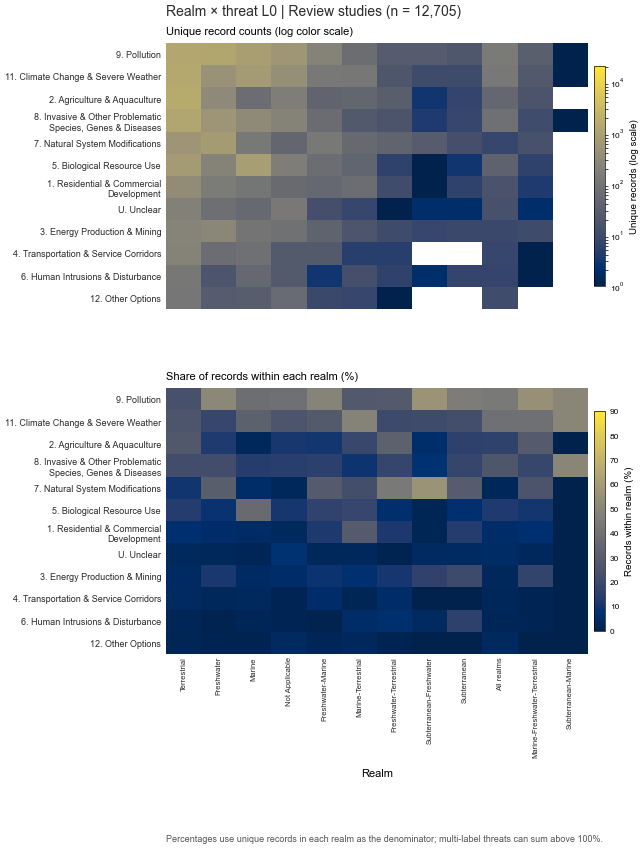

Review: unique record counts


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,1309,1243,878,597,206,67,27,27,20,134,32,1
1,Climate Change & Severe Weather,1405,461,729,396,120,116,19,10,10,121,23,1
2,Agriculture & Aquaculture,1492,302,69,165,43,46,30,3,7,50,17,0
3,"Invasive & Other Problematic Species, Genes & ...",1206,541,315,219,65,23,17,4,8,80,11,1
4,Natural System Modifications,543,747,121,47,123,54,41,27,13,8,15,0
5,Biological Resource Use,723,219,827,161,71,44,6,1,3,38,6,0
6,Residential & Commercial Development,361,143,104,57,51,70,11,1,6,16,4,0
7,Unclear,189,77,54,125,13,8,1,2,2,15,2,0
8,Energy Production & Mining,228,277,98,85,39,18,10,8,9,9,10,0
9,Transportation & Service Corridors,218,69,82,24,24,5,5,0,0,8,1,0


Review: share of records within each realm


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,24.4%,51.1%,38.8%,39.7%,49.2%,28.2%,29.0%,56.2%,45.5%,44.2%,55.2%,50.0%
1,Climate Change & Severe Weather,26.2%,18.9%,32.2%,26.3%,28.6%,48.7%,20.4%,20.8%,22.7%,39.9%,39.7%,50.0%
2,Agriculture & Aquaculture,27.8%,12.4%,3.1%,11.0%,10.3%,19.3%,32.3%,6.2%,15.9%,16.5%,29.3%,0.0%
3,"Invasive & Other Problematic Species, Genes & Diseases",22.5%,22.2%,13.9%,14.6%,15.5%,9.7%,18.3%,8.3%,18.2%,26.4%,19.0%,50.0%
4,Natural System Modifications,10.1%,30.7%,5.4%,3.1%,29.4%,22.7%,44.1%,56.2%,29.5%,2.6%,25.9%,0.0%
5,Biological Resource Use,13.5%,9.0%,36.6%,10.7%,16.9%,18.5%,6.5%,2.1%,6.8%,12.5%,10.3%,0.0%
6,Residential & Commercial Development,6.7%,5.9%,4.6%,3.8%,12.2%,29.4%,11.8%,2.1%,13.6%,5.3%,6.9%,0.0%
7,Unclear,3.5%,3.2%,2.4%,8.3%,3.1%,3.4%,1.1%,4.2%,4.5%,5.0%,3.4%,0.0%
8,Energy Production & Mining,4.3%,11.4%,4.3%,5.7%,9.3%,7.6%,10.8%,16.7%,20.5%,3.0%,17.2%,0.0%
9,Transportation & Service Corridors,4.1%,2.8%,3.6%,1.6%,5.7%,2.1%,5.4%,0.0%,0.0%,2.6%,1.7%,0.0%


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/pdf/realm_threat_matrix_study_design_unclear.pdf
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_count_matrix_study_design_unclear.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/realms/csv/realm_threat_share_matrix_study_design_unclear.csv


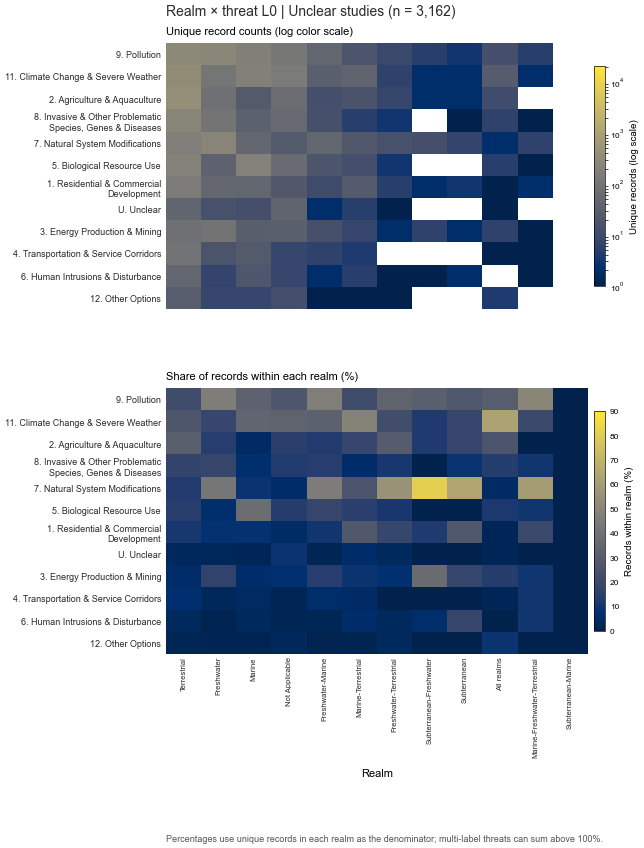

Unclear: unique record counts


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,292,258,175,115,46,18,9,5,3,13,5,0
1,Climate Change & Severe Weather,364,105,182,141,32,42,6,2,2,27,2,0
2,Agriculture & Aquaculture,421,80,25,65,13,16,8,2,2,11,0,0
3,"Invasive & Other Problematic Species, Genes & ...",236,101,35,54,14,5,3,0,1,6,1,0
4,Natural System Modifications,174,239,49,24,45,22,15,13,7,2,6,0
5,Biological Resource Use,198,37,202,59,18,13,3,0,0,5,1,0
6,Residential & Commercial Development,151,49,45,22,10,24,5,2,3,1,2,0
7,Unclear,44,15,13,40,2,5,1,0,0,1,0,0
8,Energy Production & Mining,79,96,30,31,14,8,2,6,2,6,1,0
9,Transportation & Service Corridors,92,17,24,8,6,4,0,0,0,1,1,0


Unclear: share of records within each realm


realm,pred_threat_l0,Terrestrial,Freshwater,Marine,Not Applicable,Freshwater-Marine,Marine-Terrestrial,Freshwater-Terrestrial,Subterranean-Freshwater,Subterranean,All realms,Marine-Freshwater-Terrestrial,Subterranean-Marine
0,Pollution,21.5%,46.0%,33.0%,27.0%,46.5%,20.9%,33.3%,31.2%,27.3%,30.2%,50.0%,0.0%
1,Climate Change & Severe Weather,26.8%,18.7%,34.3%,33.1%,32.3%,48.8%,22.2%,12.5%,18.2%,62.8%,20.0%,0.0%
2,Agriculture & Aquaculture,31.0%,14.3%,4.7%,15.3%,13.1%,18.6%,29.6%,12.5%,18.2%,25.6%,0.0%,0.0%
3,"Invasive & Other Problematic Species, Genes & Diseases",17.4%,18.0%,6.6%,12.7%,14.1%,5.8%,11.1%,0.0%,9.1%,14.0%,10.0%,0.0%
4,Natural System Modifications,12.8%,42.6%,9.2%,5.6%,45.5%,25.6%,55.6%,81.2%,63.6%,4.7%,60.0%,0.0%
5,Biological Resource Use,14.6%,6.6%,38.1%,13.8%,18.2%,15.1%,11.1%,0.0%,0.0%,11.6%,10.0%,0.0%
6,Residential & Commercial Development,11.1%,8.7%,8.5%,5.2%,10.1%,27.9%,18.5%,12.5%,27.3%,2.3%,20.0%,0.0%
7,Unclear,3.2%,2.7%,2.5%,9.4%,2.0%,5.8%,3.7%,0.0%,0.0%,2.3%,0.0%,0.0%
8,Energy Production & Mining,5.8%,17.1%,5.7%,7.3%,14.1%,9.3%,7.4%,37.5%,18.2%,14.0%,10.0%,0.0%
9,Transportation & Service Corridors,6.8%,3.0%,4.5%,1.9%,6.1%,4.7%,0.0%,0.0%,0.0%,2.3%,10.0%,0.0%


In [19]:
realm_threat_figure_paths_by_study_design = {}
realm_threat_table_paths_by_study_design = {}

for study_design in study_design_order:
    tables = realm_threat_tables_by_study_design[study_design]
    study_n = int(
        study_design_record_counts.loc[
            study_design_record_counts["study_design"].eq(study_design), "record_count"
        ].iloc[0]
    )
    filename_slug = study_design.lower().replace(" " , "_")
    study_fig = plot_realm_threat_matrices(
        tables["counts"],
        tables["shares"],
        f"Realm × threat L0 | {study_design} studies (n = {study_n:,})",
        count_vmax=study_design_count_vmax,
        share_vmax=study_design_share_vmax,
    )
    realm_threat_figure_paths_by_study_design[study_design] = save_figure_result(
        study_fig, f"realm_threat_matrix_study_design_{filename_slug}"
    )
    realm_threat_table_paths_by_study_design[study_design] = {
        "counts": save_table_result(
            tables["counts"].reset_index(),
            f"realm_threat_count_matrix_study_design_{filename_slug}",
        ),
        "shares": save_table_result(
            tables["shares"].reset_index(),
            f"realm_threat_share_matrix_study_design_{filename_slug}",
        ),
    }
    plt.show()

    print(f"{study_design}: unique record counts")
    display(tables["counts"].reset_index())
    print(f"{study_design}: share of records within each realm")
    # Format only the numeric realm columns; pred_threat_l0 is a string label column.
    display(tables["shares"].reset_index().style.format("{:.1%}", subset=realm_order))

## Threat distribution across geography — research specialization

Restricted to **Observational** negative-impact studies. For each place and threat
we report the **location quotient (LQ)**, i.e. research specialization:

`LQ = (threat's share of a place's documents) / (threat's share of the whole corpus)`

plotted as a symmetric **log2 fold-change** (0 = corpus average, +1 = twice the
expected emphasis, −1 = half). All terms are counts of **unique documents** (never
inflated by multi-label mentions); the geolocatable universe is documents with at
least one mapped country *and* one threat label, and the global baseline is taken
within this same subset. Non-mappable geography tokens are skipped and reported in
the audit. Geography is always derived from `pred_countries` (ISO3) and then
aggregated, so the country and subregion maps are one signal at two resolutions.

Two maps are produced:

- **Primary — IPBES subregion (17 units).** Every subregion is well sampled, so
  there is no small-N noise; this is the fix for the washed-out share map.
- **Supplementary — country level**, with countries below **100 documents** shown
  grey (`support` cutoff).

Colour is diverging (purple = under-represented, green = over-represented, white =
as expected). The raw unique-document count tables are still exported for the volume
view.

**Read this as research emphasis, not impact:** the maps show where a threat is
disproportionately *studied*, not where it *occurs*. Full design and rationale:
`checklists/repo-readmes/results/geography-research-specialization.md`.

In [20]:
# Country-level counts per threat L0, joined to the IPBES polygon vocabulary.
# The geography maps are restricted to Observational study designs within the
# eligible negative-impact corpus, so the geography reflects negative evidence from
# observational studies specifically.
# geo_counts parses pred_countries (ISO 3166-1 alpha-3), skips non-mappable tokens
# but reports them, and returns unique-document counts (never inflated mention
# counts): n = documents with (threat, country); group_total = documents with the
# threat that are geolocatable; share = n / group_total.
from data_helpers.analysis.parked.geography import geo_counts, load_crosswalk, load_polygons

geo_source_df = eligible_negative_df.loc[
    eligible_negative_df["pred_study_design"].astype("string").str.strip().eq("Observational")
].copy()
print(
    f"Geography maps use {geo_source_df['UT'].nunique():,} Observational "
    f"negative-impact records (of {eligible_negative_df['UT'].nunique():,} total)."
)

geo_country_long, geo_country_audit = geo_counts(
    geo_source_df, level="country", by="pred_threat_l0", id_col="UT", verbose=False
)
print(geo_country_audit.summary())

# Enrich with country / region names for readability, then order columns.
crosswalk = load_crosswalk()
geo_country_long = (
    geo_country_long
    .merge(crosswalk[["iso3", "country", "region", "subregion"]], on="iso3", how="left")
    .rename(columns={"n": "record_count", "group_total": "threat_record_count"})
    .loc[:, ["pred_threat_l0", "iso3", "country", "region", "subregion",
             "record_count", "threat_record_count", "share"]]
    .sort_values(["pred_threat_l0", "record_count"], ascending=[True, False])
    .reset_index(drop=True)
)

# Panel / row order: threats by number of geolocatable documents, descending.
geo_threat_order = (
    geo_country_long.groupby("pred_threat_l0", observed=True)["threat_record_count"]
    .first().sort_values(ascending=False).index.tolist()
)

# Raw unique-record count matrix and share matrix (threat rows x country columns).
geo_country_count_matrix = (
    geo_country_long.pivot_table(index="pred_threat_l0", columns="iso3",
                                 values="record_count", fill_value=0)
    .reindex(index=geo_threat_order).astype(int)
)
geo_country_share_matrix = (
    geo_country_long.pivot_table(index="pred_threat_l0", columns="iso3",
                                 values="share", fill_value=0.0)
    .reindex(index=geo_threat_order)
)

# Audit as a saveable table: totals plus per-bucket mention counts.
geo_country_audit_table = pd.DataFrame(
    [{"metric": "records_total", "value": geo_country_audit.records_total},
     {"metric": "records_without_geography", "value": geo_country_audit.records_without_geography}]
    + [{"metric": f"mentions_{bucket}", "value": count}
       for bucket, count in geo_country_audit.bucket_mentions.items()]
)

geo_country_long_path = save_table_result(geo_country_long, "geo_country_threat_long")
geo_country_count_matrix_path = save_table_result(
    geo_country_count_matrix.reset_index(), "geo_country_threat_count_matrix"
)
geo_country_share_matrix_path = save_table_result(
    geo_country_share_matrix.reset_index(), "geo_country_threat_share_matrix"
)
geo_country_audit_path = save_table_result(geo_country_audit_table, "geo_country_audit")

# Raw comparison table: the 15 countries with the most documents overall.
geo_top_countries = (
    geo_country_long.groupby(["iso3", "country"], observed=True)["record_count"]
    .sum().sort_values(ascending=False).head(15).rename("total_records").reset_index()
)
print("Top countries by total document count (raw)")
display(geo_top_countries)
print("Raw unique-record counts (threat x country); see CSV for all columns")
display(geo_country_count_matrix)

Geography maps use 116,684 Observational negative-impact records (of 253,081 total).


country: 116,684 records; 6,462 with no geography ([] -> unclear)
    mapped         :  152,114 mentions
    not_applicable :   12,164 mentions
    unclear        :    2,616 mentions
    unresolved     :      950 mentions
    unresolved tokens: TAN (412), MAD (142), ROM (103), BUL (46), NEP (34), CAM (32), KOS (21), DEN (18), POR (18), CRO (14), BAN (13), locales [ (7), SOL (7), URU (7), HON (7)
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/csv/geo_country_threat_long.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/csv/geo_country_threat_count_matrix.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/csv/geo_country_threat_share_matrix.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/csv/geo_country_audit.csv
Top countries by total 

,iso3,country,total_records
0,USA,United States of America (the),21127
1,CHN,China,17953
2,BRA,Brazil,8096
3,IND,India,6507
4,CAN,Canada,5772
5,AUS,Australia,5300
6,ESP,Spain,4210
7,ITA,Italy,3761
8,MEX,Mexico,3216
9,ZAF,South Africa,2396


Raw unique-record counts (threat x country); see CSV for all columns


iso3,ABW,AFG,AGO,AIA,ALB,AND,ARE,ARG,ARM,ASM,...,VGB,VIR,VNM,VUT,WLF,WSM,YEM,ZAF,ZMB,ZWE
pred_threat_l0,,,,,,,,,,,,,,,,,,,,,
Pollution,2,8,8,0,45,0,32,388,16,8,...,2,18,196,3,0,1,7,407,32,61
Agriculture & Aquaculture,0,13,21,1,11,1,6,485,9,0,...,0,0,226,2,0,2,7,306,59,63
Climate Change & Severe Weather,0,20,19,3,19,1,12,165,9,4,...,1,10,100,2,0,3,10,249,37,47
"Invasive & Other Problematic Species, Genes & Diseases",2,2,3,2,20,2,8,298,11,3,...,3,7,67,2,2,3,6,527,27,40
Natural System Modifications,0,8,14,0,17,1,6,186,9,0,...,1,2,105,1,0,0,3,238,22,36
Biological Resource Use,1,8,38,2,20,1,14,205,6,8,...,2,5,182,4,0,8,7,301,57,54
Residential & Commercial Development,1,4,10,1,10,0,10,91,2,3,...,1,3,90,0,0,1,3,151,8,25
Energy Production & Mining,0,0,7,0,9,0,2,39,2,0,...,0,0,62,0,0,0,0,58,24,18
Transportation & Service Corridors,3,2,6,0,3,1,2,52,1,0,...,0,1,25,0,0,0,1,54,9,7


subregion: 116,684 records; 6,462 with no geography ([] -> unclear)
    mapped         :  108,561 mentions
    not_applicable :    9,756 mentions
    unclear        :    2,133 mentions
    unresolved     :      642 mentions
    unresolved tokens: TAN (276), MAD (93), ROM (72), BUL (33), CAM (22), NEP (20), KOS (17), DEN (15), POR (11), BAN (9), CRO (7), URU (5), BUR (4), locales [ (4), RO (3)
    universe: 97,926 documents | subregions with LQ: 17 of 18 at support >= 100 | EB shrinkage kappa=30


country: 116,684 records; 6,462 with no geography ([] -> unclear)
    mapped         :  108,561 mentions
    not_applicable :    9,756 mentions
    unclear        :    2,133 mentions
    unresolved     :      642 mentions
    unresolved tokens: TAN (276), MAD (93), ROM (72), BUL (33), CAM (22), NEP (20), KOS (17), DEN (15), POR (11), BAN (9), CRO (7), URU (5), BUR (4), locales [ (4), RO (3)
    universe: 97,926 documents | countrys with LQ: 108 of 237 at support >= 100 | EB shrinkage kappa=30
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/csv/geo_lq_subregion_threat_long.csv
Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/csv/geo_lq_country_threat_long.csv


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_choropleth.pdf


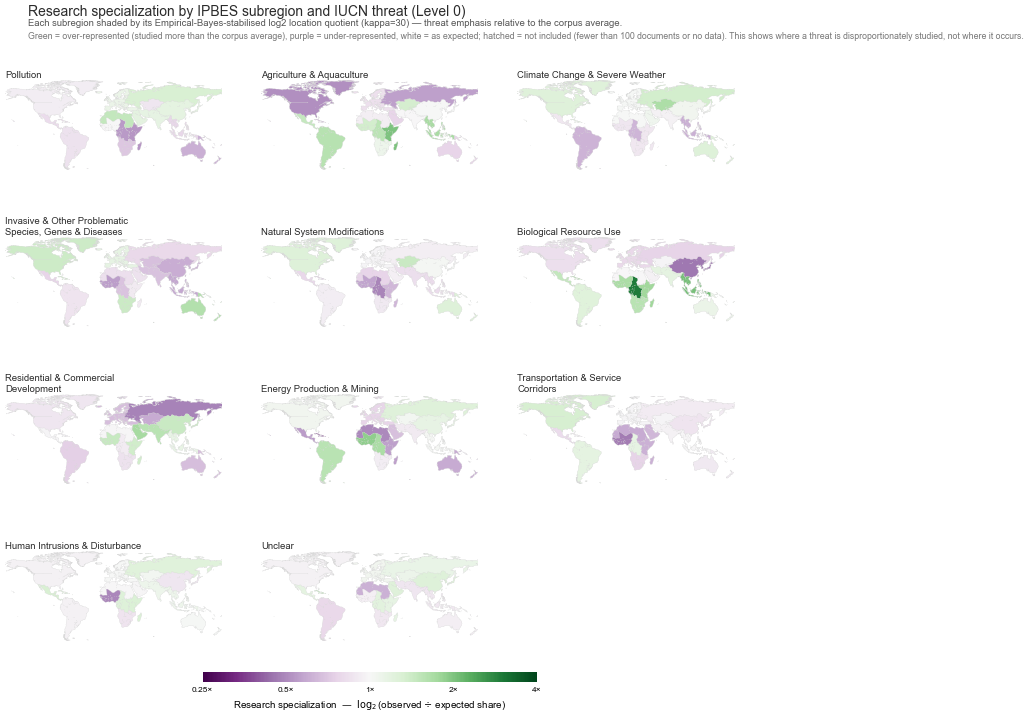

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_choropleth.pdf


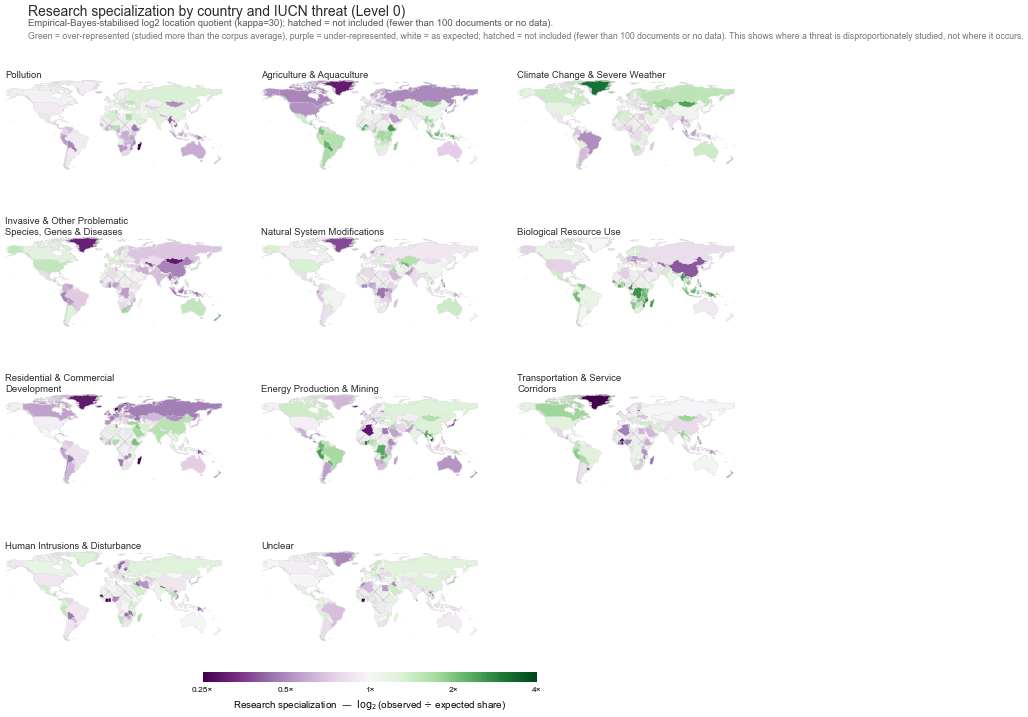

In [21]:
# Research specialization (location quotient) choropleths, replacing the % -share map.
# LQ[c,t] = (n[c,t]/D[c]) / (T[t]/D), all terms UNIQUE documents; plotted as a
# symmetric log2 fold-change on a diverging scale (white = corpus average).
# Empirical-Bayes shrinkage (kappa) stabilises small country x threat cells by
# pulling them toward 1 in proportion to their uncertainty; big genuine cells barely
# move and n=0 cells get a finite value (no arbitrary floor). The country cutoff is
# kept for coverage; not-included places are cross-hatched. Full design in
# checklists/repo-readmes/results/geography-research-specialization.md
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
import matplotlib.ticker as mticker

from data_helpers.analysis.parked.geography import location_quotient

LQ_MIN_SUPPORT = 100   # minimum documents in a place before its LQ is shown (coverage)
LQ_EB_KAPPA = 30       # Empirical-Bayes prior strength (pseudo-count); gentle stabiliser
LQ_CAP = 2.0           # clamp log2(LQ) to +/- this (1/4x .. 4x)
LQ_VALUE_COL = "log2_lq_eb"   # the stabilised value the maps display

geo_lq_subregion, geo_lq_subregion_audit = location_quotient(
    geo_source_df, level="subregion", by="pred_threat_l0", id_col="UT",
    min_support=LQ_MIN_SUPPORT, eb_kappa=LQ_EB_KAPPA, verbose=True,
)
geo_lq_country, geo_lq_country_audit = location_quotient(
    geo_source_df, level="country", by="pred_threat_l0", id_col="UT",
    min_support=LQ_MIN_SUPPORT, eb_kappa=LQ_EB_KAPPA, verbose=True,
)

# Panel order: threats by document count (class_total); "Other Options" omitted.
geo_lq_plot_order = [
    threat
    for threat in geo_lq_country.groupby("pred_threat_l0", observed=True)["class_total"]
    .first().sort_values(ascending=False).index.tolist()
    if threat != "Other Options"
]

geo_lq_subregion_path = save_table_result(geo_lq_subregion, "geo_lq_subregion_threat_long")
geo_lq_country_path = save_table_result(geo_lq_country, "geo_lq_country_threat_long")

lq_norm = Normalize(vmin=-LQ_CAP, vmax=LQ_CAP)
# PRGn (ColorBrewer, colourblind-safe): purple = under-represented, green = over.
lq_cmap = plt.get_cmap("PRGn")
LQ_GREY = "#EFEFEF"          # base fill for not-included places
LQ_HATCH_COLOR = "#B4B4B4"   # cross-hatch marking not-included places
plt.rcParams["hatch.linewidth"] = 0.3
LQ_CAVEAT = (
    "Green = over-represented (studied more than the corpus average), purple = under-represented, "
    "white = as expected; hatched = not included (fewer than 100 documents or no data). "
    "This shows where a threat is disproportionately studied, not where it occurs."
)


def plot_lq_map(polygons, geom_key, lq_long, key_col, title, subtitle, filename,
                value_col=LQ_VALUE_COL):
    sufficient = set(lq_long.loc[lq_long["sufficient"], key_col])
    n_cols = 3
    n_rows = (len(geo_lq_plot_order) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7.6, 1.55 * n_rows + 1.0))
    axes = list(axes.flat)

    for ax, threat in zip(axes, geo_lq_plot_order):
        threat_lq = lq_long.loc[lq_long["pred_threat_l0"].eq(threat), [key_col, value_col]]
        merged = polygons.merge(threat_lq, left_on=geom_key, right_on=key_col, how="left")
        included = merged[geom_key].isin(sufficient) & merged[value_col].notna()
        merged["value_clipped"] = merged[value_col].clip(-LQ_CAP, LQ_CAP)
        # Base fill for all; not-included places get a cross-hatch (EB gives every
        # sufficient cell a finite value, so no zero floor is needed); coloured on top.
        merged.plot(ax=ax, color=LQ_GREY, edgecolor=BIODIVERSITY["neutral"], linewidth=0.12)
        not_included = merged.loc[~included]
        if len(not_included):
            not_included.plot(ax=ax, facecolor="none", edgecolor=LQ_HATCH_COLOR,
                              linewidth=0.0, hatch="xx")
        placed = merged.loc[included]
        if len(placed):
            placed.plot(ax=ax, column="value_clipped", cmap=lq_cmap, norm=lq_norm,
                        edgecolor=BIODIVERSITY["neutral"], linewidth=0.12)
        ax.set_xlim(-170, 180)
        ax.set_ylim(-58, 84)  # trim Antarctica whitespace
        ax.set_axis_off()
        ax.set_title(textwrap.fill(threat, 32), loc="left", fontsize=6.8,
                     color=BIODIVERSITY["ink"], pad=2)

    for ax in axes[len(geo_lq_plot_order):]:
        ax.set_visible(False)

    fig.suptitle(title, x=0.05, y=0.995, ha="left", fontsize=10, color=BIODIVERSITY["ink"])
    fig.text(0.05, 0.975, subtitle, ha="left", va="top", fontsize=6.8, color="#555555")
    fig.text(0.05, 0.957, LQ_CAVEAT, ha="left", va="top", fontsize=6.3, color="#777777")

    cax = fig.add_axes([0.28, 0.055, 0.44, 0.013])
    cbar = fig.colorbar(ScalarMappable(norm=lq_norm, cmap=lq_cmap), cax=cax,
                        orientation="horizontal")
    cbar.set_label(r"Research specialization  —  $\log_2$(observed $\div$ expected share)",
                   fontsize=7)
    cbar.set_ticks([-2, -1, 0, 1, 2])
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{2.0 ** v:g}×"))
    cbar.ax.tick_params(labelsize=6, length=0)
    cbar.outline.set_visible(False)

    fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.10, hspace=0.5, wspace=0.18)
    return save_figure_result(fig, filename)


# Primary: subregion polygons dissolve away internal country borders for a clean map.
geo_lq_subregion_polygons = load_polygons(
    simplify_tolerance=0.2, preserve_topology=False, dissolve_by="Sub_Region"
)
geo_lq_country_polygons = load_polygons(simplify_tolerance=0.2, preserve_topology=False)

geo_lq_subregion_paths = plot_lq_map(
    geo_lq_subregion_polygons, "Sub_Region", geo_lq_subregion, "subregion",
    "Research specialization by IPBES subregion and IUCN threat (Level 0)",
    f"Each subregion shaded by its Empirical-Bayes-stabilised log2 location quotient "
    f"(kappa={LQ_EB_KAPPA}) — threat emphasis relative to the corpus average.",
    "geo_lq_subregion_choropleth",
)
plt.show()

geo_lq_country_paths = plot_lq_map(
    geo_lq_country_polygons, "ISO_3", geo_lq_country, "iso3",
    "Research specialization by country and IUCN threat (Level 0)",
    f"Empirical-Bayes-stabilised log2 location quotient (kappa={LQ_EB_KAPPA}); "
    f"hatched = not included (fewer than {LQ_MIN_SUPPORT} documents or no data).",
    "geo_lq_country_choropleth",
)
plt.show()

### Per-threat maps (individual files for reuse)

The same location-quotient logic rendered one threat per figure, at both subregion and
country level, so each threat's specialization map can be referenced or reused on its
own. Files are written to `geography/pdf/` as `geo-lq-<level>-<threat-slug>.pdf`. Scale
(log2, ±2 cap), colours (PRGn), and the 100-document support cutoff are identical to the
combined grids above.

In [22]:
# Per-threat maps: one standalone LQ choropleth per threat, at both geography levels,
# each saved to its own file so it can be referenced / reused on its own. Same metric,
# EB stabilisation, hatching, scale and colours as the combined grids above. Files
# route to geography/pdf/ via the geo- filename prefix. Reuses the combined-map objects.
import re


def _threat_slug(threat: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", threat.lower()).strip("_")


def plot_lq_single(polygons, geom_key, lq_long, key_col, threat, level_label, filename,
                   value_col=LQ_VALUE_COL):
    sufficient = set(lq_long.loc[lq_long["sufficient"], key_col])
    fig, ax = plt.subplots(figsize=(5.8, 3.4))

    threat_lq = lq_long.loc[lq_long["pred_threat_l0"].eq(threat), [key_col, value_col]]
    merged = polygons.merge(threat_lq, left_on=geom_key, right_on=key_col, how="left")
    included = merged[geom_key].isin(sufficient) & merged[value_col].notna()
    merged["value_clipped"] = merged[value_col].clip(-LQ_CAP, LQ_CAP)
    merged.plot(ax=ax, color=LQ_GREY, edgecolor=BIODIVERSITY["neutral"], linewidth=0.15)
    not_included = merged.loc[~included]
    if len(not_included):
        not_included.plot(ax=ax, facecolor="none", edgecolor=LQ_HATCH_COLOR,
                          linewidth=0.0, hatch="xx")
    placed = merged.loc[included]
    if len(placed):
        placed.plot(ax=ax, column="value_clipped", cmap=lq_cmap, norm=lq_norm,
                    edgecolor=BIODIVERSITY["neutral"], linewidth=0.15)
    ax.set_xlim(-170, 180)
    ax.set_ylim(-58, 84)
    ax.set_axis_off()
    ax.set_title(
        f"{threat}\nResearch specialization by {level_label} (log2 location quotient)",
        loc="left", fontsize=9, color=BIODIVERSITY["ink"], pad=4,
    )

    cax = fig.add_axes([0.32, 0.08, 0.40, 0.028])
    cbar = fig.colorbar(ScalarMappable(norm=lq_norm, cmap=lq_cmap), cax=cax,
                        orientation="horizontal")
    cbar.set_ticks([-2, -1, 0, 1, 2])
    cbar.ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{2.0 ** v:g}×"))
    cbar.set_label(r"$\log_2$(observed $\div$ expected share)", fontsize=7)
    cbar.ax.tick_params(labelsize=6, length=0)
    cbar.outline.set_visible(False)
    fig.text(0.02, 0.01, textwrap.fill(LQ_CAVEAT, 150), fontsize=5.3, color="#777777")
    fig.subplots_adjust(left=0.02, right=0.98, top=0.86, bottom=0.17)

    paths = save_figure_result(fig, filename)
    plt.close(fig)  # avoid displaying every per-threat figure inline
    return paths


per_threat_lq_paths = {"subregion": {}, "country": {}}
for threat in geo_lq_plot_order:
    slug = _threat_slug(threat)
    per_threat_lq_paths["subregion"][threat] = plot_lq_single(
        geo_lq_subregion_polygons, "Sub_Region", geo_lq_subregion, "subregion",
        threat, "IPBES subregion", f"geo_lq_subregion_{slug}",
    )
    per_threat_lq_paths["country"][threat] = plot_lq_single(
        geo_lq_country_polygons, "ISO_3", geo_lq_country, "iso3",
        threat, "country", f"geo_lq_country_{slug}",
    )

print(f"Saved {len(geo_lq_plot_order)} per-threat maps x 2 levels (subregion, country) "
      f"to {OUTPUT_DIR / 'geography' / 'pdf'}.")
for threat, paths in per_threat_lq_paths["subregion"].items():
    print(f"  {_threat_slug(threat)}")

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_pollution.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_pollution.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_agriculture_aquaculture.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_agriculture_aquaculture.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_climate_change_severe_weather.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_climate_change_severe_weather.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_invasive_other_problematic_species_genes_diseases.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_invasive_other_problematic_species_genes_diseases.pdf


...

✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_residential_commercial_development.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_energy_production_mining.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_energy_production_mining.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_transportation_service_corridors.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_transportation_service_corridors.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_human_intrusions_disturbance.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_human_intrusions_disturbance.pdf
✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_subregion_unclear.pdf


✓ Saved: /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf/geo_lq_country_unclear.pdf
Saved 11 per-threat maps x 2 levels (subregion, country) to /Users/hunain/d/coding-projects/biodiversity/notebooks/results/outputs/threats_supplementary/geography/pdf.
  pollution
  agriculture_aquaculture
  climate_change_severe_weather
  invasive_other_problematic_species_genes_diseases
  natural_system_modifications
  biological_resource_use
  residential_commercial_development
  energy_production_mining
  transportation_service_corridors
  human_intrusions_disturbance
  unclear
